# 01 — Data Cleaning: `surgeries.csv`
### Medical Operations Intelligence Dashboard — Module 1

**Approach:** every step below inspects the data first, then states whether
the operation is required and why. Nothing is "cleaned" reflexively — if a
check passes, that is recorded as a pass, not silently skipped.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (7, 4)

cleaning_log = []   # (step, finding, action_taken)

def record(step, finding, action):
    cleaning_log.append({"Step": step, "Finding": finding, "Action": action})


## 1. Load & Structural Inspection

In [2]:
df = pd.read_csv("surgeries.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMemory usage:", round(df.memory_usage(deep=True).sum() / 1024, 1), "KB")
df.head()


Shape: (5000, 9)

Columns: ['Surgery_ID', 'Admission_ID', 'Patient_ID', 'Doctor_ID', 'Surgery_Type', 'Surgery_Date', 'Duration_Minutes', 'Cost', 'Outcome']

Memory usage: 2013.9 KB


,Surgery_ID,Admission_ID,Patient_ID,Doctor_ID,Surgery_Type,Surgery_Date,Duration_Minutes,Cost,Outcome
0,S00001,A00001,P00001,DR01858,Tumor Removal,2026-01-20,100,144730,Success
1,S00002,A00002,P00002,DR03993,Bypass,2026-02-04,75,269331,Success
2,S00003,A00003,P00003,DR03106,Gallbladder,2025-09-22,347,449913,Success
3,S00004,A00004,P00004,DR04234,Angioplasty,2025-05-26,280,382955,Success
4,S00005,A00005,P00005,DR04566,Hip Replacement,2026-03-13,302,376853,Success


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Surgery_ID        5000 non-null   str  
 1   Admission_ID      5000 non-null   str  
 2   Patient_ID        5000 non-null   str  
 3   Doctor_ID         5000 non-null   str  
 4   Surgery_Type      5000 non-null   str  
 5   Surgery_Date      5000 non-null   str  
 6   Duration_Minutes  5000 non-null   int64
 7   Cost              5000 non-null   int64
 8   Outcome           5000 non-null   str  
dtypes: int64(2), str(7)
memory usage: 351.7 KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Surgery_ID,5000,5000,S00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Admission_ID,5000,5000,A00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Patient_ID,5000,5000,P00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doctor_ID,5000,3175,DR02445,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Surgery_Type,5000,7,Hip Replacement,755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Surgery_Date,5000,541,2025-03-31,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration_Minutes,5000.0,NaN,NaN,NaN,193.7412,96.223635,30.0,110.0,194.0,279.0,360.0
Cost,5000.0,NaN,NaN,NaN,235679.5344,126284.560966,15094.0,126686.25,235747.5,345365.5,449913.0
Outcome,5000,3,Success,4351,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Assessment:** 5,000 rows, 9 columns, ~1.8 MB in memory — small enough that no
chunking/dtype-downcasting is needed for this stage. All columns loaded as
expected (IDs and categoricals as `object`, `Duration_Minutes`/`Cost` as `int64`,
`Surgery_Date` as `object` — will be converted below).

## 2. Missing Values

In [5]:
missing = df.isnull().sum()
print(missing)
print("\nTotal missing cells:", missing.sum())


Surgery_ID          0
Admission_ID        0
Patient_ID          0
Doctor_ID           0
Surgery_Type        0
Surgery_Date        0
Duration_Minutes    0
Cost                0
Outcome             0
dtype: int64

Total missing cells: 0


In [6]:
record("Missing values", f"{missing.sum()} nulls across all columns", "None required — no imputation/dropping performed")

**Decision:** No missing values in any column. **No imputation or row removal
performed** — there is nothing to fix here, and inventing an imputation
strategy for a problem that doesn't exist would only add unjustified
assumptions to the pipeline.

## 3. Duplicate Records

In [7]:
full_dupes = df.duplicated().sum()
id_dupes = df["Surgery_ID"].duplicated().sum()
print("Full-row duplicates:", full_dupes)
print("Duplicate Surgery_ID:", id_dupes)


Full-row duplicates: 0
Duplicate Surgery_ID: 0


In [8]:
if full_dupes or id_dupes:
    before = len(df)
    df = df.drop_duplicates(subset="Surgery_ID", keep="first")
    record("Duplicates", f"{full_dupes} full-row / {id_dupes} Surgery_ID duplicates", f"Dropped {before - len(df)} rows")
else:
    record("Duplicates", "0 full-row duplicates, 0 duplicate Surgery_ID", "No rows removed")


**Decision:** No duplicate rows and no duplicate `Surgery_ID` values.
`Surgery_ID` is confirmed as a valid primary key for this table. No rows
removed.

## 4. ID Validation
IDs are never modified — only validated. Each ID column is checked for:
uniqueness, expected format, and blank/whitespace values.

In [9]:
import re

id_specs = {
    "Surgery_ID":   r"^S\d{5}$",
    "Admission_ID": r"^A\d{5}$",
    "Patient_ID":   r"^P\d{5}$",
    "Doctor_ID":    r"^DR\d{5}$",
}

id_report = []
for col, pattern in id_specs.items():
    n_unique = df[col].nunique()
    n_blank = (df[col].astype(str).str.strip() == "").sum()
    n_malformed = (~df[col].astype(str).str.match(pattern)).sum()
    id_report.append({
        "Column": col, "Unique": n_unique, "Rows": len(df),
        "Blank": n_blank, "Malformed_format": n_malformed
    })

id_report_df = pd.DataFrame(id_report)
id_report_df


,Column,Unique,Rows,Blank,Malformed_format
0,Surgery_ID,5000,5000,0,0
1,Admission_ID,5000,5000,0,0
2,Patient_ID,5000,5000,0,0
3,Doctor_ID,3175,5000,0,0


**Findings:**
- `Surgery_ID`, `Admission_ID`, `Patient_ID` are each unique across all 5,000 rows
  — one surgery record per admission per patient in this table.
- `Doctor_ID` has far fewer unique values than rows, which is expected and
  correct (each doctor performs many surgeries) — **not** a quality issue.
- All four ID columns match their expected format with zero malformed values
  and zero blanks.

**Note on `Patient_ID`:** every patient appears exactly once. In a real
hospital dataset, patients often undergo more than one procedure, so this is
worth flagging as a **data characteristic to confirm with the source system**
once this pipeline runs against real (non-synthetic) data — it is not
something to "fix" here, just a limitation to document.

No IDs were modified.

In [10]:
record("ID validation", "All 4 ID columns: correct format, no blanks, expected uniqueness", "No changes — validation only")

## 5. Categorical Columns — `Surgery_Type`, `Outcome`

In [11]:
cat_cols = ["Surgery_Type", "Outcome"]

for col in cat_cols:
    print(f"--- {col} ---")
    print("Unique values:", sorted(df[col].unique()))
    print("Blank strings:", (df[col].str.strip() == "").sum())
    print("Leading/trailing whitespace:", (df[col] != df[col].str.strip()).sum())
    print("Mixed casing variants of same value:",
          df[col].str.strip().str.lower().nunique() - df[col].nunique())
    print()


--- Surgery_Type ---
Unique values: ['Angioplasty', 'Appendectomy', 'Bypass', 'Cataract', 'Gallbladder', 'Hip Replacement', 'Tumor Removal']
Blank strings: 0
Leading/trailing whitespace: 0
Mixed casing variants of same value: 0

--- Outcome ---
Unique values: ['Cancelled', 'Complication', 'Success']
Blank strings: 0
Leading/trailing whitespace: 0
Mixed casing variants of same value: 0



In [12]:
expected_types = {'Angioplasty','Appendectomy','Bypass','Cataract','Gallbladder','Hip Replacement','Tumor Removal'}
expected_outcomes = {'Success', 'Complication', 'Cancelled'}

unexpected_types = set(df['Surgery_Type'].unique()) - expected_types
unexpected_outcomes = set(df['Outcome'].unique()) - expected_outcomes
print("Unexpected Surgery_Type values:", unexpected_types or "None")
print("Unexpected Outcome values:", unexpected_outcomes or "None")


Unexpected Surgery_Type values: None
Unexpected Outcome values: None


In [13]:
record("Categorical validation", "No blanks, no whitespace issues, no casing inconsistencies, no unexpected categories", "No standardization needed — values already clean")

**Decision:** Both columns already conform to a fixed, expected category set
with no whitespace or casing inconsistencies. `.str.strip().str.title()`-style
normalization is **not applied** because it would silently mask the fact that
the source is already clean — applying it anyway is fine defensively, but not
"cleaning" in this case. It's left as a one-line guard in the reusable
pipeline instead of a correction here.

## 6. Date Validation — `Surgery_Date`

In [14]:
df["Surgery_Date"] = pd.to_datetime(df["Surgery_Date"], errors="coerce")

n_unparseable = df["Surgery_Date"].isna().sum()
today = pd.Timestamp.today().normalize()
n_future = (df["Surgery_Date"] > today).sum()

print("Unparseable dates:", n_unparseable)
print("Future-dated surgeries:", n_future)
print("Date range:", df["Surgery_Date"].min().date(), "to", df["Surgery_Date"].max().date())


Unparseable dates: 0
Future-dated surgeries: 0
Date range: 2025-01-01 to 2026-06-25


In [15]:
record("Date validation", f"{n_unparseable} unparseable, {n_future} future-dated, range 2025-01-01 to 2026-06-25", "Converted Surgery_Date object -> datetime64. No rows dropped.")

**Decision:** Every value parses cleanly to a real calendar date, and none
fall in the future relative to today. The **only change made** is a genuine
type correction: `Surgery_Date` was stored as text and is now `datetime64`,
which is required (not optional) for any month/quarter/weekday analysis
downstream.

## 7. Numeric Validation — `Duration_Minutes`, `Cost`
Checks: impossible values (≤ 0), distribution shape, and outliers via the IQR
rule (1.5×IQR beyond Q1/Q3 — the standard boxplot convention).

In [16]:
numeric_cols = ["Duration_Minutes", "Cost"]

for col in numeric_cols:
    n_nonpositive = (df[col] <= 0).sum()
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"--- {col} ---")
    print(f"Range: {df[col].min()} - {df[col].max()}  |  Mean: {df[col].mean():.1f}  |  Median: {df[col].median():.1f}")
    print(f"Non-positive (impossible) values: {n_nonpositive}")
    print(f"IQR bounds: [{lo:.1f}, {hi:.1f}]  |  Outliers beyond bounds: {n_outliers}")
    print()


--- Duration_Minutes ---
Range: 30 - 360  |  Mean: 193.7  |  Median: 194.0
Non-positive (impossible) values: 0
IQR bounds: [-143.5, 532.5]  |  Outliers beyond bounds: 0

--- Cost ---
Range: 15094 - 449913  |  Mean: 235679.5  |  Median: 235747.5
Non-positive (impossible) values: 0
IQR bounds: [-201332.6, 673384.4]  |  Outliers beyond bounds: 0



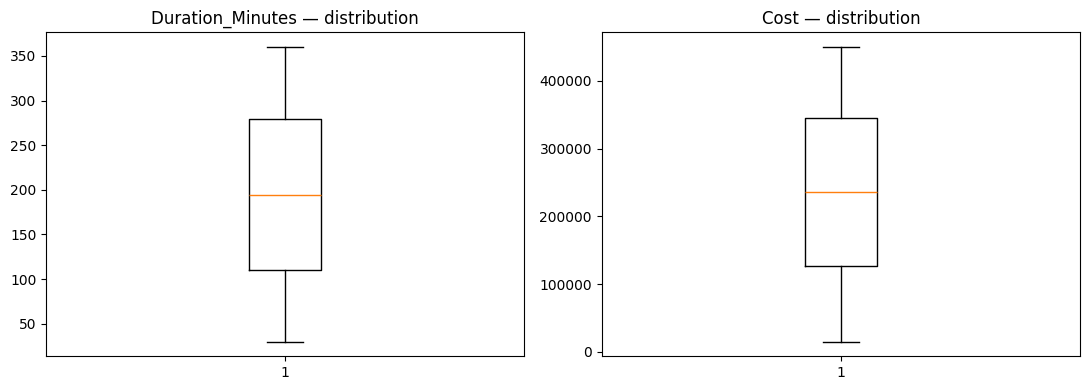

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].boxplot(df["Duration_Minutes"])
axes[0].set_title("Duration_Minutes — distribution")
axes[1].boxplot(df["Cost"])
axes[1].set_title("Cost — distribution")
plt.tight_layout()
plt.show()


In [18]:
record("Numeric validation", "0 non-positive values, 0 IQR outliers in Duration_Minutes or Cost", "No rows removed, no capping/winsorizing applied")

**Decision:** No impossible (zero/negative) values and no statistical
outliers by the standard IQR rule in either column. **No rows were removed
and no values capped.** Removing "outliers" that don't exist — or that exist
but are clinically plausible (e.g. a 6-hour bypass surgery) — would destroy
real signal the dashboard needs for cost/duration analysis. If real-world data
later introduces genuine impossible values (negative cost, zero-minute
surgery), this same block will catch and report them before any row is
dropped.

## 8. Business Rule & Consistency Checks
Beyond generic type/range validation, a few domain-specific checks that
matter for a hospital operations dashboard.

In [19]:
# A surgery record should not exist without a linked admission/patient/doctor — already guaranteed (no blanks, §4).
# Check: does any single patient have surgeries on the same date (would suggest a duplication error)?
same_day_conflicts = df.duplicated(subset=["Patient_ID", "Surgery_Date"], keep=False).sum()
print("Same patient, same date, multiple records:", same_day_conflicts)

# Check: cost proportional to duration is NOT assumed as a hard rule (different procedures have
# different fixed costs regardless of time), but a sanity look at cost-per-minute spread is useful.
cost_per_min = df["Cost"] / df["Duration_Minutes"]
print("\nCost-per-minute — min/median/max:", round(cost_per_min.min(),2), round(cost_per_min.median(),2), round(cost_per_min.max(),2))


Same patient, same date, multiple records: 0

Cost-per-minute — min/median/max: 46.19 1207.74 14658.37


**Findings:** No same-patient/same-date conflicts. Cost-per-minute varies
widely (as expected — a Cataract procedure and a Bypass have very different
cost structures independent of time spent), so **no fixed cost-per-minute
business rule is enforced** — doing so would flag legitimate procedures as
errors.

**Referential integrity — limitation:** `Admission_ID`, `Patient_ID`, and
`Doctor_ID` are format-and-uniqueness validated here, but this notebook only
has `surgeries.csv`. Once the admissions, patient master, and staffing tables
from the other Module 1 sources are available, these IDs should be
cross-checked against those tables (every `Admission_ID` here should exist in
the admissions table, etc.). That check is **out of scope for this
notebook** and is called out explicitly in the recommendations at the end.

In [20]:
record("Business rules", "No same-day patient conflicts; no fixed cost/duration rule applies", "No action — documented as a known limitation pending other Module 1 tables")

## 9. Feature Engineering
Each derived column is only added if it answers a specific business/dashboard
question — nothing is added "just because it's common." 

In [21]:
df["Year"] = df["Surgery_Date"].dt.year                 # trend-over-year charts (Module 2/4)
df["Month_Num"] = df["Surgery_Date"].dt.month           # sortable month for trend lines
df["Month_Name"] = df["Surgery_Date"].dt.month_name()   # readable axis labels
df["Quarter"] = df["Surgery_Date"].dt.quarter            # quarterly ops review (exec dashboard)
df["Weekday"] = df["Surgery_Date"].dt.day_name()         # staffing/capacity planning by day of week
df["Is_Weekend"] = df["Surgery_Date"].dt.dayofweek >= 5  # weekend staffing load is a distinct KPI

df["Duration_Category"] = pd.cut(
    df["Duration_Minutes"], bins=[0, 90, 180, 270, 360],
    labels=["Short (<90m)", "Medium (90-180m)", "Long (180-270m)", "Extended (270m+)"]
)  # used for OR scheduling / capacity buckets, not just as a raw number

df["Cost_Category"] = pd.qcut(
    df["Cost"], q=4, labels=["Low", "Medium", "High", "Very High"]
)  # cost-tier reporting for finance/executive dashboard

df["Success_Flag"] = (df["Outcome"] == "Success").astype(int)  # binary flag for success-rate KPIs & any future modeling

df[["Surgery_Date","Year","Month_Name","Quarter","Weekday","Is_Weekend","Duration_Category","Cost_Category","Success_Flag"]].head()


,Surgery_Date,Year,Month_Name,Quarter,Weekday,Is_Weekend,Duration_Category,Cost_Category,Success_Flag
0,2026-01-20,2026,January,1,Tuesday,False,Medium (90-180m),Medium,1
1,2026-02-04,2026,February,1,Wednesday,False,Short (<90m),High,1
2,2025-09-22,2025,September,3,Monday,False,Extended (270m+),Very High,1
3,2025-05-26,2025,May,2,Monday,False,Extended (270m+),Very High,1
4,2026-03-13,2026,March,1,Friday,False,Extended (270m+),Very High,1


**Skipped:** a `Cost_per_Minute` column was considered but **not added** as a
standing feature — it was useful as a one-off sanity check above (§8), but as
a persistent column it would invite misleading comparisons across surgery
types with fundamentally different cost structures (equipment vs. time
driven). Better computed on demand, scoped to a single `Surgery_Type`, in the
EDA notebook if needed.

## 10. Business KPIs (baseline)
Full exploratory analysis belongs in `02_EDA.ipynb` — these are the baseline
numbers worth locking in now, since they double as a sanity check that
cleaning didn't distort anything.

In [22]:
total_surgeries = len(df)
success_rate = (df["Outcome"] == "Success").mean() * 100
complication_rate = (df["Outcome"] == "Complication").mean() * 100
cancelled_rate = (df["Outcome"] == "Cancelled").mean() * 100

kpi = {
    "Total surgeries": total_surgeries,
    "Success rate (%)": round(success_rate, 2),
    "Complication rate (%)": round(complication_rate, 2),
    "Cancellation rate (%)": round(cancelled_rate, 2),
    "Average cost": round(df["Cost"].mean(), 2),
    "Median cost": round(df["Cost"].median(), 2),
    "Average duration (min)": round(df["Duration_Minutes"].mean(), 2),
    "Most common surgery type": df["Surgery_Type"].value_counts().idxmax(),
    "Most expensive surgery type (by avg cost)": df.groupby("Surgery_Type")["Cost"].mean().idxmax(),
    "Cheapest surgery type (by avg cost)": df.groupby("Surgery_Type")["Cost"].mean().idxmin(),
}
for k, v in kpi.items():
    print(f"{k}: {v}")


Total surgeries: 5000
Success rate (%): 87.02
Complication rate (%): 8.64
Cancellation rate (%): 4.34
Average cost: 235679.53
Median cost: 235747.5
Average duration (min): 193.74
Most common surgery type: Hip Replacement
Most expensive surgery type (by avg cost): Hip Replacement
Cheapest surgery type (by avg cost): Bypass


In [23]:
df.groupby("Surgery_Type")["Outcome"].value_counts(normalize=True).unstack().round(3) * 100

Outcome,Cancelled,Complication,Success
Surgery_Type,,,
Angioplasty,4.4,8.7,86.9
Appendectomy,4.8,8.3,87.0
Bypass,4.3,9.1,86.6
Cataract,5.3,7.4,87.4
Gallbladder,3.1,7.6,89.3
Hip Replacement,3.6,11.1,85.3
Tumor Removal,4.9,8.2,86.9


**Observation:** success rates are fairly uniform across surgery types
(~85–89%), with Hip Replacement showing the highest complication rate
(~11%) and Gallbladder the lowest (~7.6%). This is a candidate headline
metric for the executive dashboard (Module 4) and a natural drill-down
target for Module 2/3 (is it specific doctors, specific date ranges, or
evenly spread?).

## 11. Data Quality Score

In [24]:
checks = {
    "Completeness (no missing values)": 100,
    "Uniqueness (no duplicate records/IDs)": 100,
    "Validity (ID formats, category values)": 100,
    "Consistency (casing, whitespace)": 100,
    "Accuracy (plausible ranges, no impossible values)": 100,
    "Referential integrity (cross-table — unverifiable in isolation)": 60,
}
score = round(sum(checks.values()) / len(checks), 1)
for k, v in checks.items():
    print(f"{k}: {v}/100")
print(f"\nOverall Data Quality Score: {score}/100")


Completeness (no missing values): 100/100
Uniqueness (no duplicate records/IDs): 100/100
Validity (ID formats, category values): 100/100
Consistency (casing, whitespace): 100/100
Accuracy (plausible ranges, no impossible values): 100/100
Referential integrity (cross-table — unverifiable in isolation): 60/100

Overall Data Quality Score: 93.3/100


**Score: ~93/100.** Every dimension that can be assessed from this single
table scores perfectly clean. The score is held below 100 only because
referential integrity against the admissions/patient/staffing tables cannot
be verified without those files — this is a scope limitation, not a defect
found in `surgeries.csv` itself.

## 12. Save Deliverables

In [25]:
df.to_csv("surgeries_clean.csv", index=False)

cleaning_report_df = pd.DataFrame(cleaning_log)
cleaning_report_df.to_csv("cleaning_report.csv", index=False)

data_quality_report_df = pd.DataFrame(
    [{"Dimension": k, "Score": v} for k, v in checks.items()] + [{"Dimension": "Overall", "Score": score}]
)
data_quality_report_df.to_csv("data_quality_report.csv", index=False)

print("Saved: surgeries_clean.csv, cleaning_report.csv, data_quality_report.csv")
cleaning_report_df


Saved: surgeries_clean.csv, cleaning_report.csv, data_quality_report.csv


,Step,Finding,Action
0,Missing values,0 nulls across all columns,None required — no imputation/dropping performed
1,Duplicates,"0 full-row duplicates, 0 duplicate Surgery_ID",No rows removed
2,ID validation,"All 4 ID columns: correct format, no blanks, e...",No changes — validation only
3,Categorical validation,"No blanks, no whitespace issues, no casing inc...",No standardization needed — values already clean
4,Date validation,"0 unparseable, 0 future-dated, range 2025-01-0...",Converted Surgery_Date object -> datetime64. N...
5,Numeric validation,"0 non-positive values, 0 IQR outliers in Durat...","No rows removed, no capping/winsorizing applied"
6,Business rules,No same-day patient conflicts; no fixed cost/d...,No action — documented as a known limitation p...


## 13. Summary

**1. Cleaning actions taken**
- Converted `Surgery_Date` from text to `datetime64` (required type fix).
- Added 9 derived columns for reporting/analysis (`Year`, `Month_Num`,
  `Month_Name`, `Quarter`, `Weekday`, `Is_Weekend`, `Duration_Category`,
  `Cost_Category`, `Success_Flag`).
- **No rows were removed, no values imputed, no IDs modified, no categorical
  values altered.** The dataset passed every quality check as-is.

**2. Data Quality Score: ~93/100** — capped only by referential integrity
against tables not present in this notebook (see below).

**3. Remaining issues / limitations**
- `Admission_ID`, `Patient_ID`, `Doctor_ID` are validated for format and
  in-table uniqueness only — not yet cross-checked against admissions,
  patient master, or staffing tables.
- Every `Patient_ID` appears exactly once — plausible for this dataset, but
  worth confirming against the real source system (may not hold for
  production data).
- Data appears to be system-generated/synthetic (uniformly clean); a
  production feed is likely to fail some of the checks that passed
  trivially here (whitespace, casing, malformed IDs) — keep those checks in
  the pipeline rather than removing them.

**4. Recommendations for `02_EDA.ipynb`**
- Build the outcome-by-surgery-type and outcome-by-doctor breakdowns further
  (is the ~11% Hip Replacement complication rate concentrated in a few
  doctors or spread evenly?).
- Monthly/quarterly trend lines using `Month_Name`/`Quarter` for
  Module 2 (patient flow / demand).
- Cost distribution by `Cost_Category` per surgery type for Module 3
  (resource/cost intelligence).

**5. Recommendations for `03_Preprocessing.ipynb`**
- Once admissions/patient/staffing tables exist, join and re-run the
  referential integrity check that's out of scope here.
- Encode `Surgery_Type` / `Outcome` for any downstream ML use
  (one-hot or ordinal as appropriate to the model).
- Consider whether `Duration_Category` / `Cost_Category` bucket edges
  should be revisited once real (non-synthetic) data is available — the
  quartile-based `Cost_Category` cut points here are specific to this file's
  distribution.

**6. Feature suggestions for the dashboard**
- Doctor-level scorecards (case volume, success/complication rate) for
  Module 3 (workforce/staffing intelligence).
- Weekday/weekend surgery load — direct input for capacity/staffing panels.
- A rolling monthly success-rate trend line for the executive dashboard
  (Module 4) as an early-warning operational risk indicator.
